# **Proyecto 2**

## **Analítica Computacional para la Toma de Decisiones**

### **Integrantes**:

**Juan Camilo Gómez - 202220238 - j.gomezu@uniandes.edu.co**

**Jerónimo Rueda - 202223775 - j.ruedar2@uniandes.edu.co**


### **Librerias**

**Numpy, Pandas, Matplotlib, Seaborn, Tensorflow, Sklearn (Tests y Métricas), Mlflow**

In [ ]:
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns  
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, r2_score,classification_report)
from sklearn.ensemble import RandomForestClassifier


### **Datos**

**Cabe aclarar que el tratamiento/limpieza/manejo de los Datos es el mismo que en el Proyecto pasado. A continuación la descripción de esto del reporte del Proyecto 1**


 **Faltantes**

 
Se trataron los faltantes en los datos de la prueba Saber para la región de Valle del Cauca de la siguiente manera:

Faltantes en Categorías del Puntaje: Tras explorar los datos e investigar de la prueba se descubrió que en el 2014 se reformaron las categorías y pasaron a ser obligatorias las 5 categorías que conocemos hoy. Como las preguntas de negocio son en base a los puntajes, se eliminaron las filas con faltantes en puntajes (Siendo estas en su totalidad aquellas posteriores al 2014)


Faltantes en Estrato: Se reemplazaron por el promedio de los estratos del municipio redondeado a 0 decimales 


Faltantes en factor de Colegio Bilingüe y Carácter: Se reemplazó por “Desconocido”


Faltantes en Código del establecimiento DANE: Como todos eran el mismo colegio se reemplazó por "Desconocido (Instituto Tecnológico Gran Colombia)", no se encontró el código en Internet


Faltantes en el Area del colegio: Se reemplazó por “Rural” debido a que los faltantes eran entre estratos 0 y 2 en municipios con una baja población


Faltantes en variables de municipio: Teniendo en cuenta que había varios por registro, se rellenaba por alguno de los valores del registro. (ej. A un faltante en el municipio de presentación se le reemplazaba con el municipio de residencia)


Faltantes en Género: Se reemplazó por “Desconocido”


Faltantes en Variables de familia: Se reemplazó por “Desconocido”


Faltantes en Automóvil, Computador y Lavadora: Se reemplazó por “No” debido a que en su mayoría eran personas de estratos bajos y se asumió que al no marcar la respuesta era por algo. No se reemplazó por “Desconocido” por la pequeña cantidad (<2000)


Faltantes en Internet: Se asumió que las personas que tienen computador tienen internet, por lo que se reemplazaron por el valor del registro en cuanto al computador


Faltantes en puntaje de ingles: Se hizo una función como
 puntaje ingles_faltante=abs(corr_(ingles,matemáticas) )*puntaje_matematicas
+ abs(corr_(ingles,lectura crítica) )*puntaje_(lectura crítica)


Faltantes en desempeño en inglés: Se mapeó el puntaje de inglés del estudiante; si era menor a 27 se reemplazaba por A1, si era menor o igual a 40 se reemplazaba por A2, si era menor a 55 se reemplazaba por B1 y de lo contrario por B+. Esto debido a los percentiles de la variable en los registros.


Faltantes en los códigos de los municipios: Se mapearon los códigos faltantes con respecto al nombre del departamento




**Limpieza**


En todos y cada uno de los DataFrames usados en todos los archivos se normalizaron los nombres de los municipios, se les quitaron tildes, espacios y se reemplazaron datos aberrantes por la normalización. (ej. Calima (El Darien), Calima, Calima El Darién)

Igualmente, en cuanto a la detección de outliers no se tomó ninguna acción para depurar. Esto debido a que son puntajes reales acotados entre 0 y 500 o 0 y 100. Los desempeños extremos son vidas de colombianos, al un alumno sacar 0 o 500 no representa un error estadístico, representa un contexto, una familia, una serie de decisiones y sobre todo la vida de un estudiante, no consideramos que sea un dato depurable. Además la distribución de los datos (puntajes) hace que el percentil 90 se encuentre por debajo del 60% de las respuestas correctas, lo que hace que un puntaje de 320 (usando 1.5 desviaciones estándar) pudiese ser designado como outlier. Primordialmente, para las preguntas de negocio eran vitales todos los puntajes, eliminar outliers pudo haber subestimado brechas reales o suavizar desigualdades. Teniendo en cuenta que no había puntajes irracionales (menores a 0 o mayores a 500) no se depuraron estas categorías.

### **Carga de Datos**

In [ ]:
df = pd.read_csv("Saber 11 Datos Valle.csv")


mapaarreglo = {
    "Sin Estrato": 0,
    "Estrato 1": 1,
    "Estrato 2": 2,
    "Estrato 3": 3,
    "Estrato 4": 4,
    "Estrato 5": 5,
    "Estrato 6": 6
}

df["estrato_num"] = df["fami_estratovivienda"].map(mapaarreglo)


#df[df["fami_estratovivienda"]=="Sin Estrato"][["estrato_num", "fami_estratovivienda"]].head()

df[df["punt_lectura_critica"].isna()]["periodo"].value_counts()

df=df[df["punt_global"].notna()]
df=df.drop_duplicates()


df["estu_fechanacimiento"] = pd.to_datetime(
    df["estu_fechanacimiento"],
    format="%d/%m/%Y",
    errors="coerce"
)
df["estu_fechanacimiento"].isna().sum()

#df["estu_fechanacimiento"].describe()

#df.loc[641382, ["estu_fechanacimiento","periodo"]]

df["año"]=df["periodo"].astype(str).str[:4]



ti_menoresedad = pd.to_datetime("01/01/" + (df["año"].astype(int) - 17).astype(str),format="%d/%m/%Y")

cc_mayoresedad = pd.to_datetime("01/01/" + (df["año"].astype(int) - 18).astype(str),format="%d/%m/%Y")

reemplazofechanac = df["estu_fechanacimiento"].isna() | (df["estu_fechanacimiento"].dt.year == 1900)

df.loc[reemplazofechanac, "estu_fechanacimiento"] = np.where(
    df.loc[reemplazofechanac, "estu_tipodocumento"].eq("TI"),
    ti_menoresedad.loc[reemplazofechanac],
    cc_mayoresedad.loc[reemplazofechanac]
)
#df.loc[df["estu_fechanacimiento"].isna(), "estu_fechanacimiento"] = np.where(df["estu_tipodocumento"] == "TI",ti_menoresedad,cc_mayoresedad)
#df[df["estu_fechanacimiento"].isna()][["estu_fechanacimiento","periodo","estu_tipodocumento"]][["periodo","estu_tipodocumento"]].value_counts() 

df=df[df["año"].astype(int)>2014]

#print(df["estu_fechanacimiento"].sort_values().head(50))
#print(df["estu_fechanacimiento"].sort_values().tail(10))

reemplazos = {
    "CALIMA": "CALIMA EL DARIEN",
    "CALIMA (DARIEN)": "CALIMA EL DARIEN",
    "BUGA": "GUADALAJARA DE BUGA",
    "JAMUNDÍ": "JAMUNDI",
    "ALCALÁ": "ALCALA",
    "ANDALUCÍA": "ANDALUCIA",
    "BOLÍVAR": "BOLIVAR",
    "EL ÁGUILA": "EL AGUILA",
    "GUACARÍ": "GUACARI",
    "RIOFRÍO": "RIOFRIO",
    "LA UNIÓN": "LA UNION",
    "TULUÁ": "TULUA"
}

df["cole_mcpio_ubicacion"] = df["cole_mcpio_ubicacion"].replace(reemplazos)
#print(df["cole_mcpio_ubicacion"].unique().tolist())

['CALI', 'GUADALAJARA DE BUGA', 'JAMUNDI', 'RESTREPO', 'BUENAVENTURA', 'CALIMA EL DARIEN', 'YUMBO', 'CANDELARIA', 'TULUA', 'PALMIRA', 'CARTAGO', 'BOLIVAR', 'DAGUA', 'EL CERRITO', 'ALCALA', 'ROLDANILLO', 'SAN PEDRO', 'LA CUMBRE', 'CAICEDONIA', 'FLORIDA', 'ZARZAL', 'OBANDO', 'TRUJILLO', 'ANDALUCIA', 'VIJES', 'RIOFRIO', 'VERSALLES', 'GINEBRA', 'PRADERA', 'LA VICTORIA', 'BUGALAGRANDE', 'SEVILLA', 'GUACARI', 'ANSERMANUEVO', 'LA UNION', 'EL DOVIO', 'TORO', 'ARGELIA', 'YOTOCO', 'ULLOA', 'EL AGUILA', 'EL CAIRO']


### **Faltantes**

In [3]:
#df.isna().sum()

df[["cole_cod_mcpio_ubicacion","estrato_num"]].groupby("cole_cod_mcpio_ubicacion").value_counts()
prom_estrato=(df.groupby("cole_cod_mcpio_ubicacion")["estrato_num"].transform("mean").round())

df["estrato_num"] = df["estrato_num"].fillna(prom_estrato).astype("Int64")
df["fami_estratovivienda"]=df["fami_estratovivienda"].fillna("Estrato"+prom_estrato.astype("string")).astype("string")

#print(prom_estrato)

#df[df["cole_bilingue"].isna()].describe()
#df[["cole_bilingue","estrato_num"]].groupby("cole_bilingue").value_counts()
df["cole_bilingue"] = df["cole_bilingue"].fillna("Desconocido")
df["cole_caracter"] = df["cole_caracter"].fillna("Desconocido")
df["cole_cod_dane_establecimiento"] = df["cole_cod_dane_establecimiento"].fillna("Desconocido (Instituto Tecnológico Gran Colombia)")
df["cole_area_ubicacion"] = df["cole_area_ubicacion"].fillna("RURAL")
df["cole_cod_dane_establecimiento"] = df["cole_area_ubicacion"].fillna("RURAL")
df["estu_cod_depto_presentacion"] = df["estu_cod_depto_presentacion"].fillna(df["estu_cod_reside_depto"])
df["estu_depto_presentacion"] = df["estu_depto_presentacion"].fillna(df["estu_depto_reside"])

df["estu_cod_mcpio_presentacion"] = df["estu_cod_mcpio_presentacion"].fillna(df["estu_cod_reside_mcpio"])
df["estu_cod_reside_depto"] = df["estu_cod_reside_depto"].fillna(df["cole_depto_ubicacion"])
df["estu_cod_reside_mcpio"] = df["estu_cod_reside_mcpio"].fillna(df["cole_mcpio_ubicacion"])
df["estu_depto_reside"] = df["estu_depto_reside"].fillna(df["estu_depto_presentacion"])
df["estu_genero"] = df["estu_genero"].fillna("Desconocido")
df["estu_mcpio_presentacion"] = df["estu_mcpio_presentacion"].fillna(df["cole_mcpio_ubicacion"])
df["estu_mcpio_reside"] = df["estu_mcpio_reside"].fillna(df["cole_mcpio_ubicacion"])

df["fami_cuartoshogar"] = df["fami_cuartoshogar"].fillna("Desconocido")
df["fami_educacionmadre"] = df["fami_educacionmadre"].fillna("Desconocido")
df["fami_educacionpadre"] = df["fami_educacionpadre"].fillna("Desconocido")
df["fami_personashogar"] = df["fami_personashogar"].fillna("Desconocido")
df["fami_tieneautomovil"] = df["fami_tieneautomovil"].fillna("No")
df["fami_tienecomputador"] = df["fami_tienecomputador"].fillna("No")
df["fami_tieneinternet"] = df["fami_tieneinternet"].fillna(df["fami_tienecomputador"])
df["fami_tienelavadora"] = df["fami_tienelavadora"].fillna("No")




#df[df["cole_area_ubicacion"].isna()].head()
#df[["cole_cod_dane_establecimiento","cole_cod_mcpio_ubicacion"]]["cole_cod_dane_establecimiento"].isna().groupby(df["cole_cod_mcpio_ubicacion"]).value_counts()
#df[df["cole_cod_dane_establecimiento"].isna()]["cole_nombre_establecimiento"].value_counts()
df[df["desemp_ingles"].isna()]["estrato_num"].value_counts()
#df["fami_tienecomputador"].value_counts()

corr_mat = df[["punt_ingles", "punt_matematicas", "punt_lectura_critica"]].corr()
c_mat = abs(corr_mat["punt_ingles"]["punt_matematicas"])
c_lec = abs(corr_mat["punt_ingles"]["punt_lectura_critica"])
suma_c = c_mat + c_lec
reemplazo = ((c_mat / suma_c) * df["punt_matematicas"] + (c_lec / suma_c) * df["punt_lectura_critica"])
df["punt_ingles"] = df["punt_ingles"].fillna(round(reemplazo, 0))


df[df["desemp_ingles"].isna()]["punt_ingles"].describe()



"""
if df["punt_ingles"]<27:

    df["desemp_ingles"]=df["desemp_ingles"].fillna("A1")

elif df["punt_ingles"]<=40:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("A2")
elif df["punt_ingles"]<55:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B1")
else:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B+")
"""

condiciones = [df["punt_ingles"] < 27,df["punt_ingles"] <= 40,df["punt_ingles"] < 55]
valores = ["A1", "A2", "B1"]
#df["desemp_ingles"].value_counts()

nivel_calc = np.select(condiciones, valores, default="B+")

df["desemp_ingles"] = df["desemp_ingles"].fillna(pd.Series(nivel_calc, index=df.index))


categorias= df.columns.tolist()
df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'CALI': 76001}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'GUADALAJARA DE BUGA': 76111}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'BUGALAGRANDE': 76113}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'EL CERRITO': 76248}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'JAMUNDÍ': 76364}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'YUMBO': 76892}, inplace=True)
df["año"]=df["periodo"].astype(str).str[:4]

df=df[df["año"].astype(int)>2014]
df.isna().sum()


C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_13620\3873154715.py:82: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_13620\3873154715.py:82: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downca

periodo                          0
estu_tipodocumento               0
estu_consecutivo                 0
cole_area_ubicacion              0
cole_bilingue                    0
cole_calendario                  0
cole_caracter                    0
cole_cod_dane_establecimiento    0
cole_cod_dane_sede               0
cole_cod_depto_ubicacion         0
cole_cod_mcpio_ubicacion         0
cole_codigo_icfes                0
cole_depto_ubicacion             0
cole_genero                      0
cole_jornada                     0
cole_mcpio_ubicacion             0
cole_naturaleza                  0
cole_nombre_establecimiento      0
cole_nombre_sede                 0
cole_sede_principal              0
estu_cod_depto_presentacion      0
estu_cod_mcpio_presentacion      0
estu_cod_reside_depto            0
estu_cod_reside_mcpio            0
estu_depto_presentacion          0
estu_depto_reside                0
estu_estadoinvestigacion         0
estu_estudiante                  0
estu_fechanacimiento

### **Puntajes a Variables Categóricas**

In [28]:
puntajes=df.copy()


puntajes["Puntaje area ubicacion"] = puntajes["cole_area_ubicacion"].map({"URBANO": 1, "RURAL": 0})
puntajes["Puntaje bilingue"] = puntajes["cole_bilingue"].map({"S": 1, "N": 0})
#puntajes["Puntaje calendario"] = puntajes["cole_calendario"].map({"A": 1, "B": 2,"OTROS": 3})
#puntajes["Puntaje caracter"] = puntajes["cole_caracter"].map({"TÉCNICO/ACADÉMICO": 1, "ACADÉMICO": 2,"TÉCNICO": 3,"NO APLICA": 4})
puntajes["Puntaje Genero col"] = puntajes["cole_genero"].map({"MIXTO": 1, "FEMENINO": 2,"MASCULINO": 3})
puntajes["Puntaje Jornada"] = puntajes["cole_jornada"].map({"MAÑANA": 1, "TARDE": 2,"COMPLETA": 3,"NOCHE": 4,"UNICA": 5,"SABATINA":6})
puntajes["Puntaje Naturaleza"] = puntajes["cole_naturaleza"].map({"OFICIAL": 1, "NO OFICIAL": 0})
puntajes["Puntaje Sede Principal"] = puntajes["cole_sede_principal"].map({"S": 1, "N": 0})
puntajes["Puntaje Investigación"] = puntajes["estu_estadoinvestigacion"].map({"PUBLICAR": 3, "VALIDEZ OFICINA JURÍDICA": 2,"PRESENTE CON LECTURA TARDIA":1,"NO SE COMPROBO IDENTIDAD DEL EXAMINADO":0})
#puntajes["Puntaje Genero"] = puntajes["estu_genero"].map({"M": 0, "F": 1})
puntajes["Puntaje Libertad"] = puntajes["estu_privado_libertad"].map({"S": 0, "N": 1})
puntajes["Puntaje Cuartos Hogar"] = puntajes["fami_cuartoshogar"].map({"Uno": 1, "Dos": 2,"Tres": 3,"Cuatro": 4,"Cinco": 5,"Seis":6,"Seis o mas": 6.5,"Siete": 7,"Ocho": 8,"Nueve": 9,"Diez o más": 10})

puntajes["Puntaje Educación Madre"] = puntajes["fami_educacionmadre"].map({"No Aplica":0,"No sabe":1,"Ninguno":2,"Primaria incompleta":3,
                                                                           "Primaria completa":4,"Secundaria (Bachillerato) incompleta":5,
                                                                           "Secundaria (Bachillerato) completa":6,"Técnica o tecnológica completa":7,
                                                                           "Técnica o tecnológica incompleta":8,"Educación profesional incompleta":9,
                                                                           "Educación profesional completa":10,"Postgrado":11})

puntajes["Puntaje Educación Padre"] = puntajes["fami_educacionpadre"].map({"No Aplica":0,"No sabe":1,"Ninguno":2,"Primaria incompleta":3,
                                                                           "Primaria completa":4,"Secundaria (Bachillerato) incompleta":5,
                                                                           "Secundaria (Bachillerato) completa":6,"Técnica o tecnológica completa":7,
                                                                           "Técnica o tecnológica incompleta":8,"Educación profesional incompleta":9,
                                                                           "Educación profesional completa":10,"Postgrado":11})

puntajes["Puntaje Personas Hogar"] = puntajes["fami_personashogar"].map({"Una": 1, "1 a 2":1.5,"Dos": 2,"Tres": 3,"3 a 4":3.5,"Cuatro": 4,"Cinco": 5,
                                                                         "5 a 6":5.5,"Seis": 6,"Siete": 7,"7 a 8":7.5,"Ocho": 8,"Nueve": 9,"9 o más":9.5,
                                                                         "Diez": 10,"Doce o más": 10})
puntajes["Puntaje Automóvil"] = puntajes["fami_tieneautomovil"].map({"Si": 1, "No": 0})
puntajes["Puntaje Computador"] = puntajes["fami_tienecomputador"].map({"Si": 1, "No": 0})

puntajes["Puntaje Lavadora"] = puntajes["fami_tienelavadora"].map({"Si": 1, "No": 0})
puntajes["Puntaje Desempeño ingles"] = puntajes["desemp_ingles"].map({"A-":0,"A1": 1, "A2": 2,"B1": 3,"B+": 4})
puntajes["Puntaje Internet"] = puntajes["fami_tieneinternet"].map({"Si": 1, "No": 0})


puntajes["desemp_ingles"].value_counts()
def normalizar(s):
    return (s.str.normalize("NFKD")
                .str.encode("ascii","ignore")
                .str.decode("utf-8").str.upper()
                .str.strip())
puntajes["cole_mcpio_ubicacion"] = (df["cole_mcpio_ubicacion"].pipe(normalizar))
puntajes["cole_mcpio_ubicacion"] = puntajes["cole_mcpio_ubicacion"].replace(["CALIMA (DARIEN)", "CALIMA"], "CALIMA EL DARIEN")
mapazonas= {
    # Zona Pacífico 
    "BUENAVENTURA": "Pacífico",
    # Zona Centro
    "CALIMA EL DARIEN": "Centro",
    "YOTOCO": "Centro",
    "SAN PEDRO": "Centro",
    "GUADALAJARA DE BUGA": "Centro",   
    "BUGA": "Centro",                  
    "GUACARI": "Centro",
    "GINEBRA": "Centro",
    "EL CERRITO": "Centro",
    # Zona Sur 
    "DAGUA": "Sur",
    "LA CUMBRE": "Sur",
    "VIJES": "Sur",
    "YUMBO": "Sur",
    "CALI": "Sur",
    "PALMIRA": "Sur",
    "CANDELARIA": "Sur",
    "PRADERA": "Sur",
    "FLORIDA": "Sur",
    "JAMUNDI": "Sur",
    "RESTREPO": "Sur",
    # Zona Norte
    "ALCALA": "Norte",
    "ULLOA": "Norte",
    "CARTAGO": "Norte",
    "ANSERMANUEVO": "Norte",
    "EL AGUILA": "Norte",
    "EL CAIRO": "Norte",
    "VERSALLES": "Norte",
    "ARGELIA": "Norte",
    "TORO": "Norte",
    "OBANDO": "Norte",
    "LA VICTORIA": "Norte",
    "LA UNION": "Norte",
    "ROLDANILLO": "Norte",
    "ZARZAL": "Norte",
    "BOLIVAR": "Norte",
    "TRUJILLO": "Norte",
    "RIOFRIO": "Norte",
    "EL DOVIO": "Norte",
    "ANDALUCIA": "Norte",
    "BUGALAGRANDE": "Norte",
    "TULUA": "Norte",
    "SEVILLA": "Norte",
    "CAICEDONIA": "Norte"}

puntajes["Zona"] = puntajes["cole_mcpio_ubicacion"].map(mapazonas)

puntajes["Puntaje bilingue"].fillna(puntajes["Puntaje bilingue"].mode()[0],inplace=True)
ordenlogico = ["Puntaje Educación Madre","Puntaje Educación Padre","Puntaje Personas Hogar","Puntaje Cuartos Hogar"]
for col in ordenlogico:
    puntajes[col] = puntajes[col].fillna(puntajes.groupby("fami_estratovivienda")[col].transform("mean"))
puntajes["año"] = puntajes["año"].astype(int)
puntajes["Puntaje educacion padres"] = puntajes["Puntaje Educación Padre"]+puntajes["Puntaje Educación Madre"]
puntajes["Puntaje recursos hogar"] = puntajes["Puntaje Automóvil"]+puntajes["Puntaje Computador"]+puntajes["Puntaje Lavadora"]
#puntajes["Puntaje Genero"] = puntajes["estu_genero"].map({"M": 0, "F": 1})
puntajes_solonum = puntajes.iloc[:, 45:].copy()
puntajes2020s=puntajes[puntajes["año"].astype(int)>=2020]




print("Nuevas columnas listas:", ["Puntaje Caracter","Puntaje Calendario",
    "int_estrato_edu","int_urbano_estrato","int_natur_estrato"])

C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_13620\4131201112.py:99: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  puntajes["Puntaje bilingue"].fillna(puntajes["Puntaje bilingue"].mode()[0],inplace=True)


Nuevas columnas listas: ['Puntaje Caracter', 'Puntaje Calendario', 'int_estrato_edu', 'int_urbano_estrato', 'int_natur_estrato']


### **Ejemplos de las columnas**

In [29]:
columnas=puntajes2020s.columns
for i in columnas:
    print(f"Columna:{i} , Ejemplo: {puntajes2020s[i][2]}")

Columna:periodo , Ejemplo: 20224
Columna:estu_tipodocumento , Ejemplo: TI
Columna:estu_consecutivo , Ejemplo: SB11202240151458
Columna:cole_area_ubicacion , Ejemplo: URBANO
Columna:cole_bilingue , Ejemplo: N
Columna:cole_calendario , Ejemplo: A
Columna:cole_caracter , Ejemplo: TÉCNICO/ACADÉMICO
Columna:cole_cod_dane_establecimiento , Ejemplo: URBANO
Columna:cole_cod_dane_sede , Ejemplo: 176364001313.0
Columna:cole_cod_depto_ubicacion , Ejemplo: 76
Columna:cole_cod_mcpio_ubicacion , Ejemplo: 76364
Columna:cole_codigo_icfes , Ejemplo: 671156.0
Columna:cole_depto_ubicacion , Ejemplo: VALLE
Columna:cole_genero , Ejemplo: MIXTO
Columna:cole_jornada , Ejemplo: UNICA
Columna:cole_mcpio_ubicacion , Ejemplo: JAMUNDI
Columna:cole_naturaleza , Ejemplo: OFICIAL
Columna:cole_nombre_establecimiento , Ejemplo: INSTITUCION EDUCATIVA TÉCNICA INDUSTRIAL ESPAÑA
Columna:cole_nombre_sede , Ejemplo: TÉCNICA INDUSTRIAL ESPAÑA-SEDE PRINCIPAL
Columna:cole_sede_principal , Ejemplo: S
Columna:estu_cod_depto_pres

### **Semilla Aleatoria y Tamaño de Grupos de Datos**

In [6]:
semilla = 42

tamaño_test = 0.2
porcentaje=tamaño_test/(1-tamaño_test)

### **Definir $X$ (Variables de Entrada - Predictivas) y $Y$ (Variable de Salida - Predicha)**

**$ X $** : Puntaje Personas Hogar, Tiene Automóvil, Tiene Computador,Tiene Lavadora, Tiene Internet, Puntaje Inglés, Puntaje Matemáticas, Puntaje Sociales y Ciudadanas, Puntaje Ciencias Naturales, Puntaje Lectura Crítica, Nivel Desempeño Inglés, Es bilingue,

**$ Y $** : Nivel Educativo de la Madre: Separado por Básica/Sin, Secundaria, Técnica, Superior

In [109]:
mapa_clase_madre = {0:0, 1:0, 2:0, 3:0,4:1, 5:1, 6:1,7:2, 8:2,9:3, 10:3, 11:3}      


nombres_clase = ["Básica/Sin","Secundaria","Técnica","Superior"]

puntajes2020s["clase_madre"] = puntajes2020s["Puntaje Educación Madre"].round().astype(int).map(mapa_clase_madre)

Conj_num = ["Puntaje Personas Hogar",
            "Puntaje Automóvil","Puntaje Computador","Puntaje Lavadora",
            "punt_ingles", "punt_matematicas","punt_sociales_ciudadanas", "punt_c_naturales","punt_lectura_critica",
            "Puntaje Desempeño ingles","Puntaje bilingue","clase_madre","Puntaje Internet"]

#Conj_cat = []

# Mantenemos cole_mcpio_ubicacion como CLAVE (no como dummy) para hacer target encoding
base = puntajes2020s[Conj_num].copy()
#base["año"] = base["año"].astype(int)
y = base["clase_madre"].astype(int).values
y_separado = pd.qcut(y, q=10, labels=False, duplicates='drop')

idx_trainval, idx_test = train_test_split(np.arange(len(base)), test_size=0.15,
                                          random_state=semilla, stratify=y_separado)
idx_train, idx_val = train_test_split(idx_trainval, test_size=porcentaje,
                                      random_state=semilla, stratify=y_separado[idx_trainval])

# Target encoding del municipio — SOLO con train, con smoothing
mu_global = y[idx_train].mean()
X = base[Conj_num].drop(columns=["clase_madre"])
y = base["clase_madre"].astype(int).values 

idx_trainval, idx_test = train_test_split(np.arange(len(base)), test_size=0.15,
                                          random_state=semilla, stratify=y)
idx_train, idx_val = train_test_split(idx_trainval, test_size=porcentaje,
                                      random_state=semilla, stratify=y[idx_trainval])

X_train, X_val, X_test = X.iloc[idx_train], X.iloc[idx_val], X.iloc[idx_test]
X_escalar = StandardScaler()
X_train_s = X_escalar.fit_transform(X_train)
X_val_s   = X_escalar.transform(X_val)
X_test_s  = X_escalar.transform(X_test)

y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]
mapeo_educacion = {
    "Básica/Sin": 0, "Secundaria": 1, "Técnica": 2, "Superior": 3}
base["Puntaje Educación Madre"] = puntajes2020s["fami_educacionmadre"].map(mapeo_educacion).astype(float)
etiquetas_madre = [k for k in mapeo_educacion.keys()]


C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_13620\3567679680.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puntajes2020s["clase_madre"] = puntajes2020s["Puntaje Educación Madre"].round().astype(int).map(mapa_clase_madre)


### **Función para Calcular Métricas de los Modelos**

In [ ]:
def evaluar_clasif(y_true, y_pred, y_proba=None, label=''):
    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average='macro')
    adj  = np.mean(np.abs(y_true - y_pred) <= 1)
    salida = {"Accuracy":acc, "F1_macro":f1m, "Adj_Acc_+-1":adj}
    if y_proba is not None and len(np.unique(y_true))==y_proba.shape[1]:

        salida["AUC_ovr"] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')

    if label:

        print(f"  [{label}]  Acc={round(acc,3)} | F1m={round(f1m,3)} | Adj+-1={round(adj,3)}"
              
              + (f" | AUC={round(salida['AUC_ovr'],3)}" if 'AUC_ovr' in salida else ""))
    return salida

### **Correlación de las Variables de Entrada con la Variable de Salida**

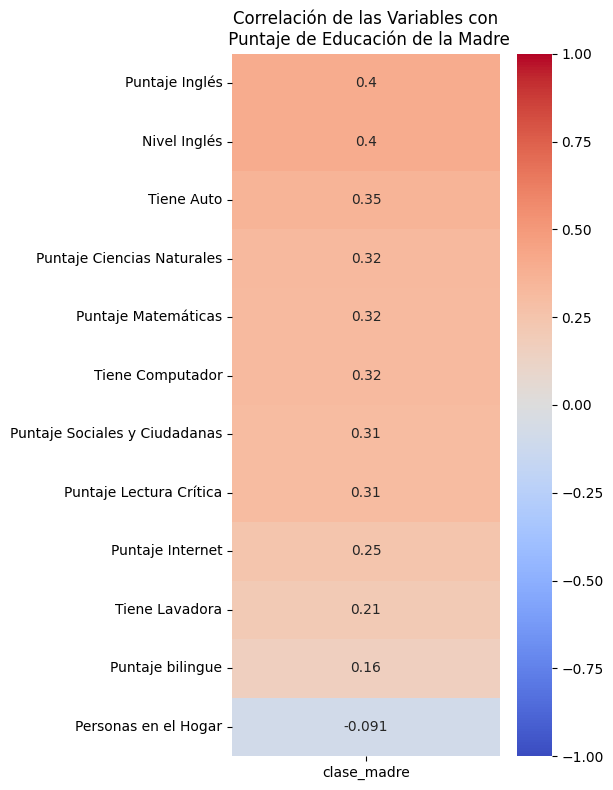

In [129]:
plt.figure(figsize=(6, 8))
basee=base[Conj_num].copy()
basee.rename(columns={"punt_ingles": "Puntaje Inglés", "punt_matematicas": "Puntaje Matemáticas"
                      , "punt_sociales_ciudadanas": "Puntaje Sociales y Ciudadanas", "punt_c_naturales": "Puntaje Ciencias Naturales", "punt_lectura_critica": "Puntaje Lectura Crítica",
                      "Puntaje Automóvil": "Tiene Auto","Puntaje Computador": "Tiene Computador", "Puntaje Lavadora": "Tiene Lavadora",
                      "Puntaje Desempeño ingles": "Nivel Inglés","Puntaje Personas Hogar": "Personas en el Hogar"}, inplace=True)
matriz_completa = basee.corr()

#Solo se usa el puntaje de educacion de la madre
corr_madre = matriz_completa[["clase_madre"]].drop("clase_madre", axis=0)
corr_madre_ordenada = corr_madre.sort_values(by="clase_madre", ascending=False)
sns.heatmap(corr_madre_ordenada, annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=True)

plt.title('Correlación de las Variables con\n Puntaje de Educación de la Madre')
plt.tight_layout()
plt.show()

### **Histograma con la Distribución de la Educación de la Madre en los Datos**

C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_13620\125737455.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='clase_madre', data=base, palette='viridis')


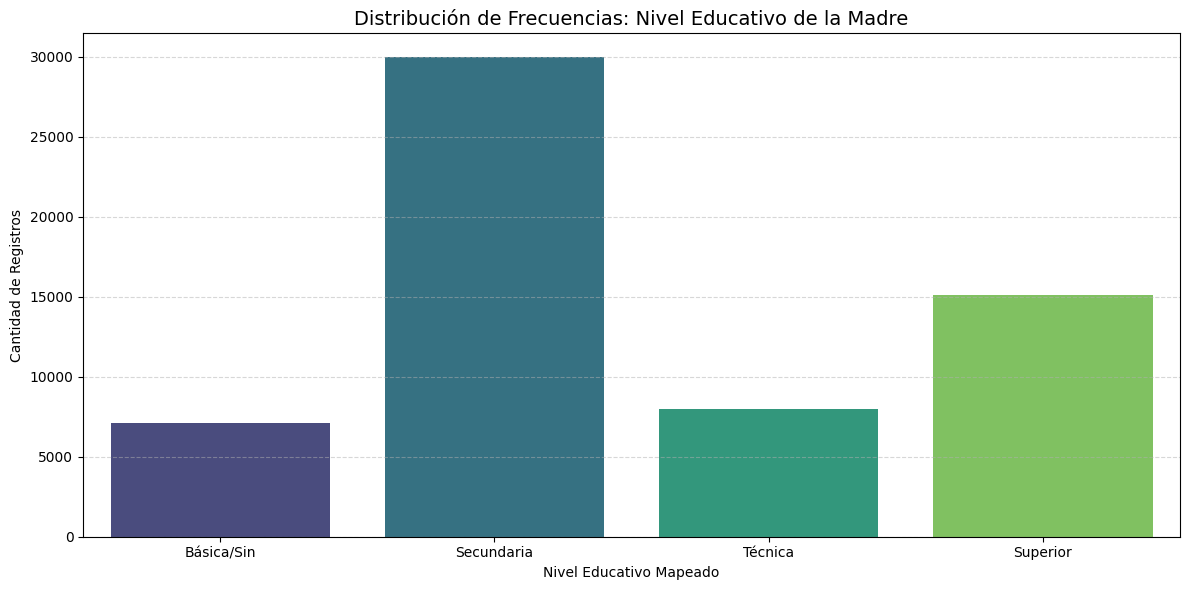

In [114]:
plt.figure(figsize=(12, 6))

# Usamos countplot ya que la variable actúa ahora como un indicador entero discreto
sns.countplot(x='clase_madre', data=base, palette='viridis')
plt.title('Distribución de Frecuencias: Nivel Educativo de la Madre', fontsize=14)
plt.xlabel('Nivel Educativo Mapeado')
plt.ylabel('Cantidad de Registros')
# Cambiar los números del eje X con las categorías originales 
plt.xticks(ticks=range(4), labels=etiquetas_madre)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Violin Plots con la Distribución de la Educación de la Madre en base a Si Tienen Lavadora o No**

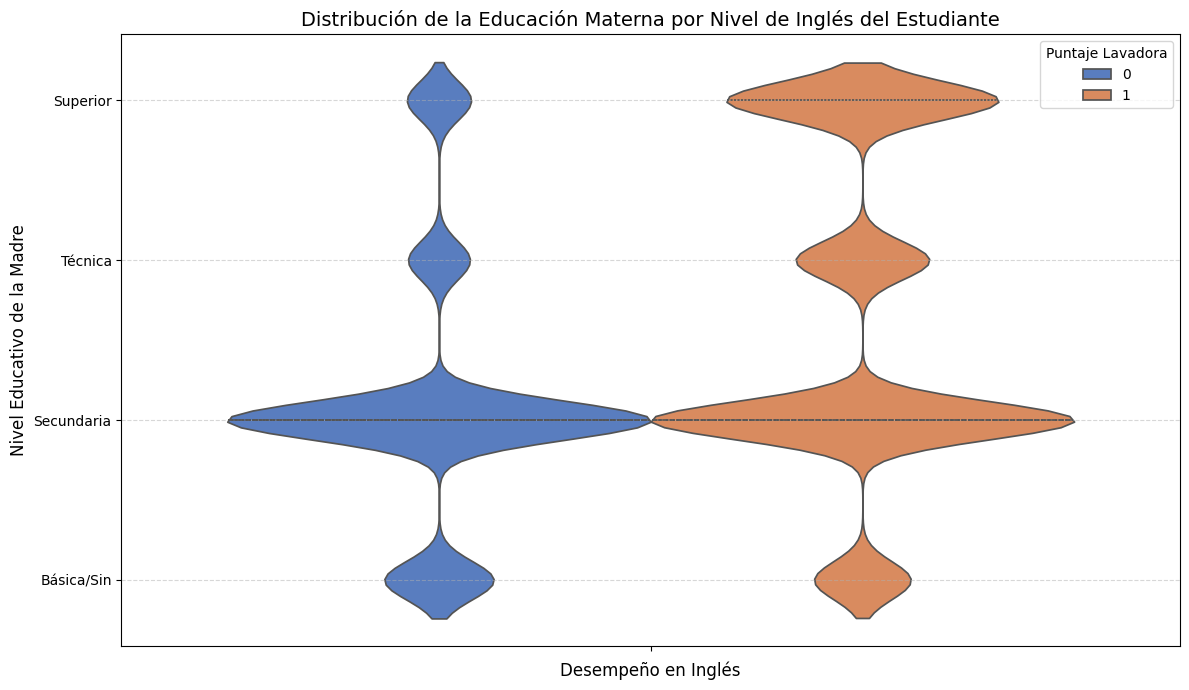

In [ ]:
plt.figure(figsize=(12, 7))

sns.violinplot(hue="Puntaje Lavadora", y='clase_madre', data=base, 
               palette='muted', inner="quartile")

plt.title('Distribución de la Educación Materna por Nivel de Inglés del Estudiante', fontsize=14)
plt.xlabel('Tiene Lavadora?', fontsize=12)
plt.ylabel('Nivel Educativo de la Madre', fontsize=12)

# Ajustamos las etiquetas del eje Y para mapear los números de vuelta a su texto original
plt.yticks(ticks=range(4), labels=etiquetas_madre, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Prueba de Diferentes Parámetros para hacer un $ \text{Modelo Random Forest} $**

Usando ***Mlflow*** para documentar los resultados

In [ ]:
mlflow.set_tracking_uri("file:./mlruns")
experimento = mlflow.set_experiment("Puntaje Prueba Saber: Pregunta Educación Madre")
n_feats = X_train.shape[1]

for n_est in [100, 300, 500]:
    for max_d in [8, 12, 16]:
        for max_f in ["sqrt", min(8, n_feats)]:
            for min_leaf in [2, 5, 20]:
                with mlflow.start_run(experiment_id=experimento.experiment_id):
                    rf = RandomForestClassifier(
                        n_estimators=n_est, max_depth=max_d, max_features=max_f,
                        min_samples_leaf=min_leaf,
                        n_jobs=-1, random_state=semilla)
                    rf.fit(X_train, y_train)
                    pred_val = rf.predict(X_val)
                    acc = accuracy_score(y_val, pred_val)
                    f1m = f1_score(y_val, pred_val, average='macro')
                    adj = np.mean(np.abs(y_val - pred_val) <= 1)
                    mlflow.set_tag("mlflow.runName", f"RFC_{n_est}_{max_d}_{max_f}_leaf{min_leaf}")
                    mlflow.log_params({"n_estimators":n_est,"max_depth":max_d,
                                       "max_features":str(max_f),"min_samples_leaf":min_leaf})
                    mlflow.log_metrics({"Accuracy_val":acc,"F1_macro_val":f1m,"Adj_Acc_val":adj})
                    mlflow.sklearn.log_model(rf, "random_forest_model")

2026/05/24 13:11:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 13:11:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/24 13:11:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 13:11:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

### **Encontrar el Mejor Modelo Según Accuracy y sus Parámetros**

In [ ]:
mlflow.set_tracking_uri("file:./mlruns")
experimento = mlflow.get_experiment_by_name("Puntaje Prueba Saber: Pregunta Educación Madre")
runs_df = mlflow.search_runs(experiment_ids=[experimento.experiment_id])
mejor_run = runs_df.sort_values(by="metrics.Accuracy_val", ascending=False).iloc[0]

print("Parámetros del mejor modelo:")
print(f"N estimadores (n_estimators): {mejor_run['params.n_estimators']}")
print(f"Profundidad máxima (max_depth): {mejor_run['params.max_depth']}")
print(f"Características máximas (max_features): {mejor_run['params.max_features']}")
print(f"Muestras mínimas (min_samples_leaf): {mejor_run['params.min_samples_leaf']}")




Parámetros del mejor modelo:
N estimadores (n_estimators): 500
Profundidad máxima (max_depth): 8
Características máximas (max_features): sqrt
Muestras mínimas (min_samples_leaf): 5
Mejor Resultado y sus parámetros:

Nombre del Run: RFC_500_8_sqrt_leaf5
Mejor F1 Macro: 1.0000
Mejor Accuracy: 1.0000





### **Usar los Parámetros del Mejor Modelo pero experimentando con la Semilla y quitando o poniendo variables para encontrar Mejores Métricas**

 **Semillas usadas: 42, 24052026, 1234567890**

In [161]:
Conj_num = ["Puntaje Automóvil","Puntaje Computador",
            "punt_ingles", "punt_matematicas","punt_sociales_ciudadanas", "punt_c_naturales","punt_lectura_critica",
            "Puntaje Desempeño ingles","clase_madre","Puntaje Internet"]
semilla= 42

#Conj_cat = []
base = puntajes2020s[Conj_num].copy()
#base["año"] = base["año"].astype(int)
y = base["clase_madre"].astype(int).values
y_separado = pd.qcut(y, q=10, labels=False, duplicates='drop')

idx_trainval, idx_test = train_test_split(np.arange(len(base)), test_size=0.15,
                                          random_state=semilla, stratify=y_separado)
idx_train, idx_val = train_test_split(idx_trainval, test_size=porcentaje,
                                      random_state=semilla, stratify=y_separado[idx_trainval])

mu_global = y[idx_train].mean()
X = base[Conj_num].drop(columns=["clase_madre"])
y = base["clase_madre"].astype(int).values 

idx_trainval, idx_test = train_test_split(np.arange(len(base)), test_size=0.15,
                                          random_state=semilla, stratify=y)
idx_train, idx_val = train_test_split(idx_trainval, test_size=porcentaje,
                                      random_state=semilla, stratify=y[idx_trainval])

X_train, X_val, X_test = X.iloc[idx_train], X.iloc[idx_val], X.iloc[idx_test]
X_escalar = StandardScaler()
X_train_s = X_escalar.fit_transform(X_train)
X_val_s   = X_escalar.transform(X_val)
X_test_s  = X_escalar.transform(X_test)

y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

### **Modelo Random Forest Experimental**

In [163]:


n_estimators=mejor_run['params.n_estimators']
max_depth=mejor_run['params.max_depth']
max_features=mejor_run['params.max_features']
min_samples_leaf=15
with mlflow.start_run(experiment_id=experimento.experiment_id):
    rf = RandomForestClassifier(
        n_estimators=n_est, max_depth=max_d, max_features=max_f,
        min_samples_leaf=min_leaf,
        n_jobs=-1, random_state=semilla,
        class_weight='balanced_subsample',)
    rf.fit(X_train, y_train)
    pred_val = rf.predict(X_val)
    acc = accuracy_score(y_val, pred_val)
    f1m = f1_score(y_val, pred_val, average='macro')
    adj = np.mean(np.abs(y_val - pred_val) <= 1)
    mlflow.set_tag("mlflow.runName", f"RFC_{n_est}_{max_d}_{max_f}_leaf{min_leaf}")
    mlflow.log_params({"n_estimators":n_est,"max_depth":max_d,
                        "max_features":str(max_f),"min_samples_leaf":min_leaf})
    mlflow.log_metrics({"Accuracy_val":acc,"F1_macro_val":f1m,"Adj_Acc_val":adj})
    mlflow.sklearn.log_model(rf, "random_forest_model")


    

2026/05/24 23:03:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 23:03:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/24 23:05:32 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\JUANCA~1\AppData\Local\Temp\tmpbp863zp4\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


### **Nuevas Métricas**

In [ ]:
#Resultados Diferentes Semillas
res_semillas = []

res_semillas.append({semilla: [acc, f1m, adj]})
print(f"Accuracy:          {round(acc, 4)}")
print(f"F1-Score (Macro):  {round(f1m, 4)}")
print(f"Adjusted Accuracy: {round(adj, 4)}")

print(f"Resultados Diferentes Semillas:\n {res_semillas}")


: 

In [147]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)



mlflow.set_tracking_uri("file:./mlruns")
experimento = mlflow.set_experiment("Puntaje Prueba Saber: Pregunta Educación Madre - Matriz")

def evaluar_clasif(y_true, y_pred, y_proba=None, label=''):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    adj = float(np.mean(np.abs(y_true - y_pred) <= 1))
    out = {'Accuracy': acc, 'F1_macro': f1m, 'Adj_Acc_pm1': adj}
    if y_proba is not None and y_proba.shape[1] == len(np.unique(y_true)):
        out['AUC_ovr'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    if label:
        msg = f'  [{label}]  Acc={acc:.3f} | F1m={f1m:.3f} | Adj_pm1={adj:.3f}'
        if 'AUC_ovr' in out: msg += f' | AUC={out["AUC_ovr"]:.3f}'
        print(msg)
    return out

def plot_diagnostico(y_true, y_pred, titulo, nombres=None):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=nombres, yticklabels=nombres, ax=ax)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    ax.set_title(f'{titulo} — Matriz de confusión normalizada')
    plt.tight_layout(); plt.show()

=== Baseline: Random Forest Classifier ===
  [VAL ]  Acc=0.577 | F1m=0.314 | Adj_pm1=0.813 | AUC=0.685
  [TEST]  Acc=0.581 | F1m=0.318 | Adj_pm1=0.817 | AUC=0.690


2026/05/24 14:55:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


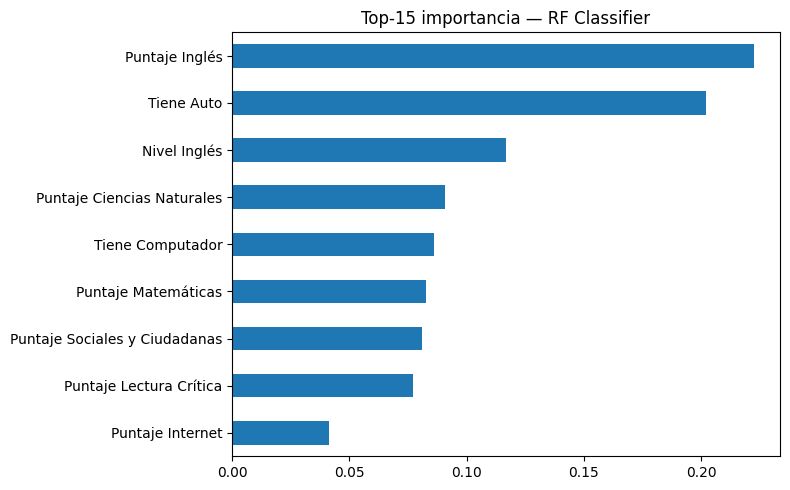

In [ ]:
with mlflow.start_run(run_name='RFC_baseline') as run:
    rf_params = dict(n_estimators=400, max_depth=14, min_samples_leaf=20,
                     n_jobs=-1, random_state=semilla)
    rf = RandomForestClassifier(**rf_params)
    rf.fit(X_train, y_train)
    pred_val   = rf.predict(X_val);    proba_val   = rf.predict_proba(X_val)
    pred_test  = rf.predict(X_test);   proba_test  = rf.predict_proba(X_test)
    m_val  = evaluar_clasif(y_val,  pred_val,  proba_val,  'VAL ')
    m_test = evaluar_clasif(y_test, pred_test, proba_test, 'TEST')
    mlflow.log_params({**rf_params, 'model_type':'RFClassifier', 'n_features':X.shape[1]})
    for k,v in m_val.items():  mlflow.log_metric(f'val_{k}', v)
    for k,v in m_test.items(): mlflow.log_metric(f'test_{k}', v)
    mlflow.sklearn.log_model(rf, name='rfc_model')


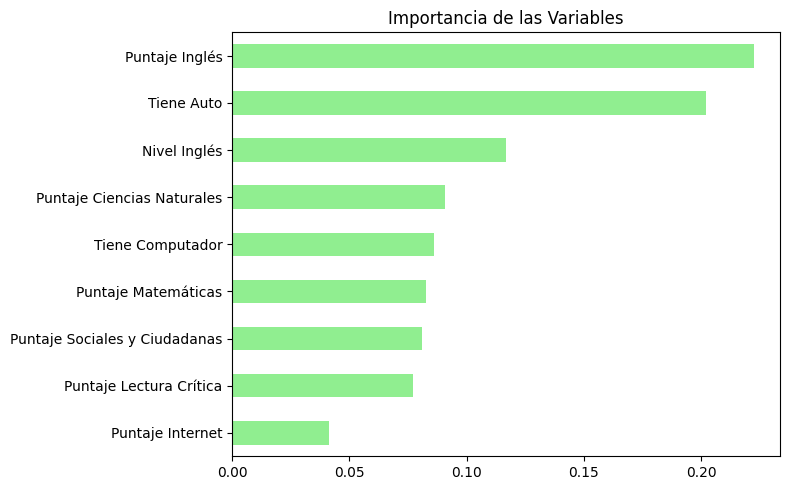

In [151]:

importancia = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(15)
nuevos_nombres = {"punt_ingles": "Puntaje Inglés", "punt_matematicas": "Puntaje Matemáticas","punt_sociales_ciudadanas": "Puntaje Sociales y Ciudadanas", 
    "punt_c_naturales": "Puntaje Ciencias Naturales", "punt_lectura_critica": "Puntaje Lectura Crítica","Puntaje Automóvil": "Tiene Auto",        
    "Puntaje Computador": "Tiene Computador","Puntaje Lavadora": "Tiene Lavadora","Puntaje Desempeño ingles": "Nivel Inglés"}
importancia.rename(index=nuevos_nombres, inplace=True)
fig, ax = plt.subplots(figsize=(8,5)); importancia.plot(kind='barh', ax=ax, color="lightgreen")
ax.set_title('Importancia de las Variables'); plt.tight_layout(); plt.show()

In [131]:
n_clases = int(y_train.max()) + 1

def hacer_redesneu(dimensiones, n_clases, ocultas=(256,128,64), dropout=0.25, l2=5e-4, lr=8e-4):
    inputs = tf.keras.Input(shape=(dimensiones,))
    x = tf.keras.layers.BatchNormalization()(inputs)
    for h in ocultas:
        x = tf.keras.layers.Dense(h, kernel_regularizer=tf.keras.regularizers.l2(l2))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(n_clases, activation='softmax')(x)
    modelo = tf.keras.Model(inputs, out)
    modelo.compile(optimizer=tf.keras.optimizers.Adam(lr),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return modelo

prueba = [
    {'Nombre':'NN_BN_pequeña', 'Capas Ocultas':(128,64),'dropout':0.20,'l2':1e-4,'lr':1e-3,'epochs':80, 'bs':256},
    {'Nombre':'NN_BN_mediana', 'Capas Ocultas':(256,128,64),'dropout':0.25,'l2':5e-4,'lr':8e-4,'epochs':120,'bs':256},
    {'Nombre':'NN_BN_grande',  'Capas Ocultas':(512,256,128,64),'dropout':0.30,'l2':1e-3,'lr':5e-4,'epochs':150,'bs':512}]

resultados, histories, models = [], {}, {}

for cfg in prueba:
    print(f'\n=== {cfg["Nombre"]} ===')
    tf.keras.backend.clear_session()
    tf.random.set_seed(semilla); np.random.seed(semilla)
    with mlflow.start_run(run_name=cfg['Nombre']) as run:
        model = hacer_redesneu(X_train_s.shape[1], n_clases,
                               cfg['Capas Ocultas'], cfg['dropout'], cfg['l2'], cfg['lr'])

        es = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss')
        rl = tf.keras.callbacks.ReduceLROnPlateau(patience=6, factor=0.5, monitor='val_loss', min_lr=1e-5)

        hist = model.fit(
            X_train_s, y_train,                          # ← y entero, no escalado
            validation_data=(X_val_s, y_val),
            epochs=cfg['epochs'], batch_size=cfg['bs'],
            callbacks=[es, rl], verbose=0)

        # Predicciones: probabilidades → clase con argmax
        proba_val  = model.predict(X_val_s,  verbose=0)
        proba_test = model.predict(X_test_s, verbose=0)
        pred_val   = proba_val.argmax(1)
        pred_test  = proba_test.argmax(1)

        m_val  = evaluar_clasif(y_val,  pred_val,  proba_val,  'VAL ')
        m_test = evaluar_clasif(y_test, pred_test, proba_test, 'TEST')

        mlflow.log_params({
            'model_type':'NeuralNetwork_Classifier',
            'hidden': str(cfg['Capas Ocultas']),
            'dropout': cfg['dropout'], 'l2': cfg['l2'], 'lr': cfg['lr'],
            'batch_size': cfg['bs'], 'epochs_max': cfg['epochs'],
            'epochs_trained': len(hist.history['loss']),
            'n_features': X.shape[1], 'n_clases': n_clases,
            'optimizer':'Adam', 'early_stopping': True
        })
        for k,v in m_val.items():  mlflow.log_metric(f'val_{k}', v)
        for k,v in m_test.items(): mlflow.log_metric(f'test_{k}', v)
        mlflow.tensorflow.log_model(model, name='Modelo Redes Neuronales')

        resultados.append({
            'modelo': cfg['Nombre'],
            **{f'val_{k}':v for k,v in m_val.items()},
            **{f'test_{k}':v for k,v in m_test.items()},
            'epochs_trained': len(hist.history['loss'])})
        histories[cfg['Nombre']] = hist
        models[cfg['Nombre']]    = model


=== NN_BN_pequeña ===


c:\Users\Juan Camilo Gómez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


  [VAL ]  Acc=0.581 | F1m=0.318 | Adj_pm1=0.817 | AUC=0.699
  [TEST]  Acc=0.583 | F1m=0.319 | Adj_pm1=0.818 | AUC=0.702


2026/05/24 13:57:26 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
c:\Users\Juan Camilo Gómez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)



=== NN_BN_mediana ===
  [VAL ]  Acc=0.580 | F1m=0.317 | Adj_pm1=0.816 | AUC=0.699
  [TEST]  Acc=0.585 | F1m=0.320 | Adj_pm1=0.819 | AUC=0.701


2026/05/24 14:02:38 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
c:\Users\Juan Camilo Gómez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)



=== NN_BN_grande ===
  [VAL ]  Acc=0.581 | F1m=0.318 | Adj_pm1=0.816 | AUC=0.700
  [TEST]  Acc=0.583 | F1m=0.320 | Adj_pm1=0.816 | AUC=0.703


2026/05/24 14:07:32 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
c:\Users\Juan Camilo Gómez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


In [152]:
top2 = np.argsort(-proba_test, axis=1)[:, :2]
hit_top2 = np.mean([y_test[i] in top2[i] for i in range(len(y_test))])
print(f"Top-2 cobertura: {hit_top2*100:.1f}%")

# Confianza del Top-1
conf_max = proba_test.max(1)
print(f"\nDistribución de confianza Top-1:")
print(pd.Series(conf_max).describe())

# Calibración por nivel de confianza
bins_conf = pd.cut(conf_max, bins=[0,.4,.5,.6,.7,.8,1.0])
calib = pd.DataFrame({'bin':bins_conf,
                      'acierto':(pred_test_best==y_test).astype(int)})
print("\nAcierto real por banda de confianza:")
print(calib.groupby('bin', observed=True)['acierto'].agg(['mean','size']).round(3))

Top-2 cobertura: 78.9%

Distribución de confianza Top-1:
count    9023.000000
mean        0.582359
std         0.111122
min         0.336033
25%         0.496996
50%         0.584292
75%         0.656009
max         0.928793
dtype: float64

Acierto real por banda de confianza:
             mean  size
bin                    
(0.0, 0.4]  0.297   340
(0.4, 0.5]  0.388  1987
(0.5, 0.6]  0.363  2770
(0.6, 0.7]  0.457  2557
(0.7, 0.8]  0.615  1067
(0.8, 1.0]  0.831   302


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

config_gbm = [
    {"name":"GBM_conservador", "max_depth":5, "lr":0.05, "max_iter":600, "min_samples_leaf":80, "l2":1.0},
    {"name":"GBM_balanceado",  "max_depth":7, "lr":0.05, "max_iter":800, "min_samples_leaf":50, "l2":0.5},
    {"name":"GBM_flexible",    "max_depth":9, "lr":0.03, "max_iter":1200,"min_samples_leaf":30, "l2":0.1},
]
gbm_results = {}
for cfg in config_gbm:
    with mlflow.start_run(run_name=cfg["name"]):
        gbm = HistGradientBoostingClassifier(
            max_iter=cfg["max_iter"], max_depth=cfg["max_depth"],
            learning_rate=cfg["lr"], l2_regularization=cfg["l2"],
            min_samples_leaf=cfg["min_samples_leaf"],             
            early_stopping=True, validation_fraction=0.15, n_iter_no_change=25,
            random_state=semilla)
        gbm.fit(X_train, y_train)
        
        # Diagnóstico de sobreajuste: train vs val vs test
        m_tr  = evaluar_clasif(y_train, gbm.predict(X_train), gbm.predict_proba(X_train), f'{cfg["name"]} TRAIN')
        m_val = evaluar_clasif(y_val,   gbm.predict(X_val),   gbm.predict_proba(X_val),   f'{cfg["name"]} VAL  ')
        m_test= evaluar_clasif(y_test,  gbm.predict(X_test),  gbm.predict_proba(X_test),  f'{cfg["name"]} TEST ')
        
        mlflow.log_params({**{k:v for k,v in cfg.items() if k!="name"}, "model_type":"HistGBMClassifier"})
        for k,v in m_val.items():  mlflow.log_metric(f"val_{k}", v)
        for k,v in m_test.items(): mlflow.log_metric(f"test_{k}", v)
        mlflow.log_metric("gap_F1_train_val", m_tr["F1_macro"] - m_val["F1_macro"])  # >0.05 = sobreajuste
        mlflow.sklearn.log_model(gbm, name=cfg["name"])
        gbm_results[cfg["name"]] = (gbm, m_val, m_test, m_tr)

  [GBM_conservador TRAIN]  Acc=0.447 | F1m=0.431 | Adj_pm1=0.846 | AUC=0.757
  [GBM_conservador VAL  ]  Acc=0.406 | F1m=0.388 | Adj_pm1=0.834 | AUC=0.708
  [GBM_conservador TEST ]  Acc=0.415 | F1m=0.395 | Adj_pm1=0.841 | AUC=0.719


2026/05/24 12:49:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [GBM_balanceado TRAIN]  Acc=0.464 | F1m=0.446 | Adj_pm1=0.848 | AUC=0.770
  [GBM_balanceado VAL  ]  Acc=0.410 | F1m=0.390 | Adj_pm1=0.834 | AUC=0.707
  [GBM_balanceado TEST ]  Acc=0.421 | F1m=0.400 | Adj_pm1=0.841 | AUC=0.719


2026/05/24 12:49:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [GBM_flexible TRAIN]  Acc=0.461 | F1m=0.445 | Adj_pm1=0.848 | AUC=0.771
  [GBM_flexible VAL  ]  Acc=0.408 | F1m=0.389 | Adj_pm1=0.833 | AUC=0.707
  [GBM_flexible TEST ]  Acc=0.418 | F1m=0.398 | Adj_pm1=0.838 | AUC=0.719


2026/05/24 12:50:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
